In [11]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [12]:
df = pd.read_csv('C:\\Users\\nayef\\OneDrive\\Desktop\\telecom-churn-analysis\\data\\raw\\telco_churn.csv')

# print the dataset shape and rows and cols
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

df.head() # display the 
df.info() # get info about the dataset

Dataset shape: (7043, 21)
Rows: 7043, Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   objec

In [13]:
# now we check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# totalCharges sum
df['TotalCharges'].describe()

# get the datatype of totalCharges
print(f"TotalCharges data type: {df['TotalCharges'].dtype}")

# check for non-numeric values 
non_numeric = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"\nRows with non-numeric TotalCharges: {len(non_numeric)}")
print(non_numeric[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

# now we analyze the churn distribution
churn_counts = df['Churn'].value_counts()
churn_rate = (churn_counts['Yes'] / len(df)) * 100

print(f"Churn rate: {churn_rate: .2f}%")
print(f"Churned: {churn_counts['Yes']}")
print(f"Not Churned: {churn_counts['No']}")



Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
TotalCharges data type: object

Rows with non-numeric TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
Churn rate:  26.54%
Churned: 1869
Not Churned: 5174


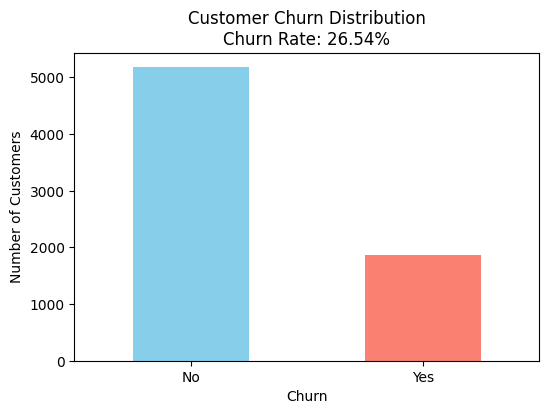

In [14]:
# visualization of the churn distribution
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title(f'Customer Churn Distribution\nChurn Rate: {churn_rate:.2f}%')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()